In [1]:
using DifferentialEquations, Plots, LinearAlgebra
# Threads.nthreads()

20

### Initialization

In [7]:
#Basis state
r = [0;1]
g = [1;0]

#initial state of the system
α = 1
β = sqrt(1-α^2)
ψ_a = α.*r + β.*g
ψ_1 = g

ψ_0 = [ψ_a,g,g]
ρ_0 = complex(reduce(kron,ψ_0) * reduce(kron,ψ_0)');

### Functions

In [8]:
struct Parameters
    Ω1::Float64
    Ω2::Float64     
    γ_Decay::Float64     
    γ_dephase::Float64
    V1_nn::Float64 
    V2_nn::Float64
    δ1::Float64   
 end

In [9]:
nothing
# Parameters
function (p::Parameters)(t)
    # global Δ1_0 = Δ1_0
    # global Δ2_0 = Δ2_0
    
    tf = -2*(Δ1_0+p.V1_nn)/p.δ1
    return (Δ1_0+p.δ1*t, Δ2_0+p.δ1*t, p.Ω1, p.Ω2, p.γ_Decay, p.γ_dephase, p.V1_nn, p.V2_nn)
end


#Master Equation
nothing
function master_eqn(dρ,ρ,p,t)

    n_atoms = 2
    #2x2 Matrices
    σ_x = [0 1; 1 0]
    n = [0 0; 0 1]
    Π_g = [1 0; 0 0]
    I = [1 0; 0 1]
    σ_minus = [0 1; 0 0]
    σ_plus = [0 0; 1 0]
    σ_z = [1 0; 0 -1]

    #parameters
    Δ1_t, Δ2_t, Ω1, Ω2, γ_Decay, γ_dephase, V1_nn, V2_nn = p(t)


    #Hamiltonian elements
    nn_sys = [kron(n,n,I), kron(I,n,n)] 
    σminus_sys = [reduce(kron,[I,σ_minus,I]),reduce(kron,[I,I,σ_minus])]
    σplus_sys = [reduce(kron,[I,σ_plus,I]), reduce(kron,[I,I,σ_plus])]
    σz_sys = [reduce(kron,[I,σ_z,I]), reduce(kron,[I,I,σ_z])]
    n_sys = [reduce(kron,[I,n,I]), reduce(kron,[I,I,n])]
    σx_sys = [reduce(kron,[I,σ_x,I]), reduce(kron,[I,I,σ_x])]

    #Hamiltonian
    H = Ω1/2 .* σx_sys[1] + Ω2/2 .* σx_sys[2] + V1_nn .* nn_sys[1] + V2_nn.* nn_sys[2] +
        Δ1_t .* n_sys[1] + Δ2_t .*n_sys[2]

    #lindbaldian terms
    l_decay = zeros(2^(n_atoms+1),2^(n_atoms+1))
    l_dephase = zeros(2^(n_atoms+1),2^(n_atoms+1))

    for i in 1:2
        l_decay += γ_Decay.*(σminus_sys[i] * ρ * σplus_sys[i] - 0.5.*((σplus_sys[i]*σminus_sys[i]*ρ)
                         + (ρ*σplus_sys[i]*σminus_sys[i])))
        l_dephase += γ_dephase.*(σz_sys[i]* ρ *σz_sys[i] - ρ)
    end

    dρ .= -1im .* (H*ρ - ρ*H) + l_decay + l_dephase
end


#Solving the master equation
nothing
function solve_master_eqn(p)
    # global δ1 = δ1
    tspan = (0.0,-2*(Δ1_0+p(0)[end-1])/p.δ1)
    eqn = ODEProblem(master_eqn, ρ_0, tspan, p)
    sol = solve(eqn, Rodas3(autodiff=false),saveat=0.01)
    return sol
end

# #Obtaining the fidelilty of |RRR> state w.r.t detuning rate
# function fid_detuning(δ)
#     # global Δ1_0 = Δ1_0
#     # global Δ2_0 = Δ2_0

#     fidelity = Array{Float64}(undef, length(δ))
#     ψ_ideal = α*kron(r,r,r) + β*kron(g,g,g)

#     Threads.@threads for i in 1:length(δ)
#         d = δ[i]
#         p = Parameters(20,20,0,0,-2000,-2000,d)
#         sol = solve_master_eqn(p)

#         f = tr(ψ_ideal' * sol[end] * ψ_ideal)
#         fidelity[i] = real(f) 
#     end
#     return fidelity
# end

fid_detuning (generic function with 1 method)

### RAP with different Detuning rate and Dephase

In [10]:
global Δ1_0 = 3000.0
global Δ2_0 = 3000.0
global δ = -1 .*collect(range(start=1000.0,stop=10,step=-10));
dephase = 10 .^ range(log10(10^-4),log10(10^0),length=10);

In [27]:
using Plots, JLD2, LaTeXStrings

@load "jl_files/2_atom_dephase.jld2" δ dephase fidelity

δ = δ;
dephase = dephase;
fidelity = fidelity;

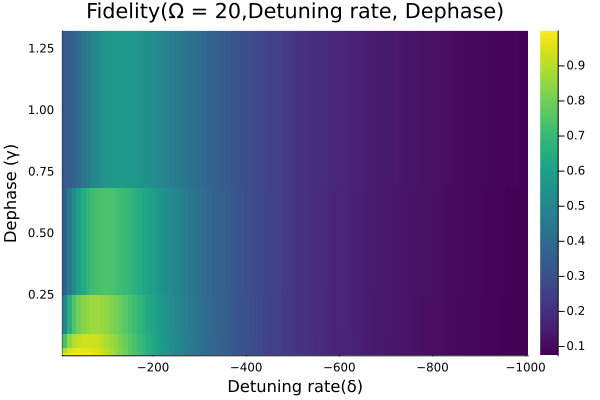

In [28]:
heatmap(δ , dephase, fidelity,
        xflip=true,
        xlabel="Detuning rate(δ)",
        ylabel="Dephase (γ)",
        title="Fidelity(Ω = 20,Detuning rate, Dephase)",
        color=:viridis)

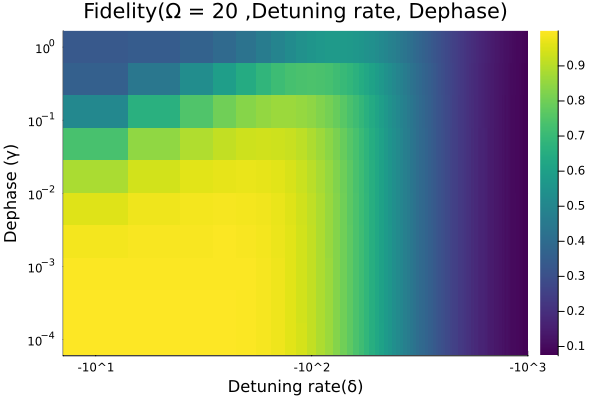

In [29]:
plt = heatmap(-1 .* log10.(-1 .* δ), dephase, fidelity,
    yscale=:log10, xflip=true,
        xlabel="Detuning rate(δ)",
        ylabel="Dephase (γ)",
        title="Fidelity(Ω = 20 ,Detuning rate, Dephase)",
        color=:viridis)

xticks = [-3, -2, -1]
xlabels = ["-10^3", "-10^2", "-10^1"]
xticks!(plt, xticks, xlabels)

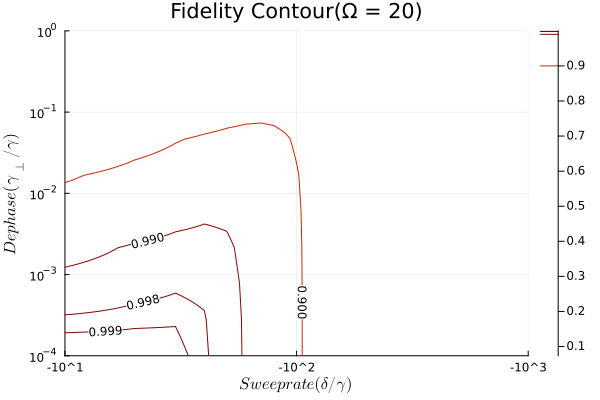

In [30]:
plt = contour(
    x_vals, 
    dephase, 
    fidelity,
    xflip=true,
    color=:turbo,
    levels=[0.9,0.99,0.998,0.999],
    yscale=:log10,
    xlabel=L"Sweep rate (\delta/\gamma)",
    ylabel=L"Dephase (\gamma_{\perp}/\gamma)",
    title="Fidelity Contour(Ω = 20)",
    clabels=true, cbar=true,lw=1
)
xticks = [-3,-2, -1, 0]
xlabels = ["-10^3","-10^2", "-10^1","-10^0"]
xticks!(plt, xticks, xlabels)

In [15]:
using Plots, JLD2, LaTeXStrings

@load "jl_files/2_atom_dephase2.jld2" δ dephase fidelity

δ = δ;
dephase = dephase;
fidelity = fidelity;

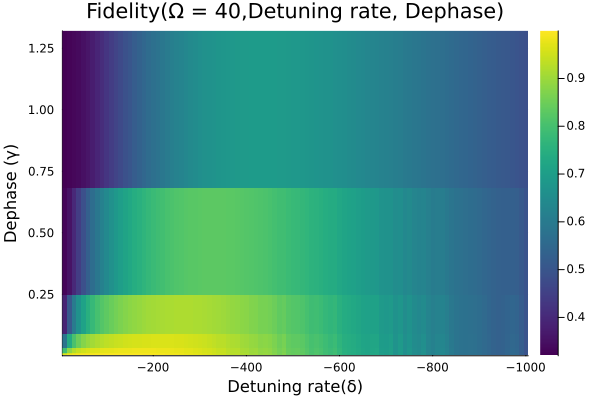

In [21]:
heatmap(δ , dephase, fidelity,
        xflip=true,
        xlabel="Detuning rate(δ)",
        ylabel="Dephase (γ)",
        title="Fidelity(Ω = 40,Detuning rate, Dephase)",
        color=:viridis)

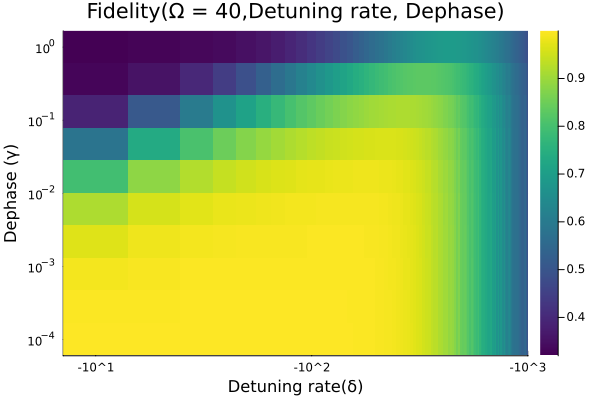

In [20]:
plt = heatmap(-1 .* log10.(-1 .* δ), dephase, fidelity,
    yscale=:log10, xflip=true,
        xlabel="Detuning rate(δ)",
        ylabel="Dephase (γ)",
        title="Fidelity(Ω = 40,Detuning rate, Dephase)",
        color=:viridis)

xticks = [-3, -2, -1]
xlabels = ["-10^3", "-10^2", "-10^1"]
xticks!(plt, xticks, xlabels)

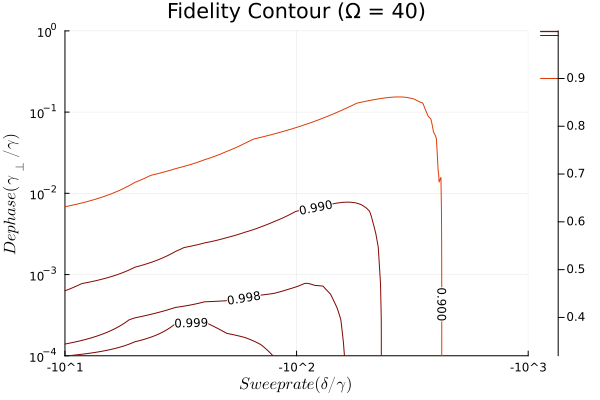

In [25]:
x_vals = -1 .* log10.(-1 .* δ)
plt = contour(
    x_vals, 
    dephase, 
    fidelity,
    xflip=true,
    color=:turbo,
    levels=[0.9,0.99,0.998,0.999],
    yscale=:log10,
    xlabel=L"Sweep rate (\delta/\gamma)",
    ylabel=L"Dephase (\gamma_{\perp}/\gamma)",
    title="Fidelity Contour (Ω = 40)",
    clabels=true, cbar=true,lw=1
)
xticks = [-3, -2, -1, 0]
xlabels = ["-10^3","-10^2", "-10^1","-10^0"]
xticks!(plt, xticks, xlabels)